In [1]:
print("Hello, Jupyter is working")


Hello, Jupyter is working


importing libraries


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


Cell 2 — Load Dataset

In [7]:
df = pd.read_csv("data/raw/shark_tank_india_raw.csv")


In [8]:
df.head()


,season,startup_name,industry,deal_made,amount_asked_lakhs,equity_asked_percent,amount_deal_lakhs,equity_given_percent,valuation_lakhs,sharks_invested,profitable
0,1,Skippi,FMCG,Yes,45,5,45,5,900,"Aman,Peyush",Yes
1,1,Blue Tea,Food & Beverage,Yes,75,1,75,1,7500,Ashneer,Yes
2,1,Hammer,Electronics,Yes,100,1,100,1,10000,Aman,Yes
3,1,Revamp Moto,Automobile,No,100,1,0,0,0,NaN,No
4,1,CosIQ,Cosmetics,Yes,50,10,50,10,500,Namita,Yes


In [9]:
df.shape

(10, 11)

In [10]:
df.columns


Index(['season', 'startup_name', 'industry', 'deal_made', 'amount_asked_lakhs',
       'equity_asked_percent', 'amount_deal_lakhs', 'equity_given_percent',
       'valuation_lakhs', 'sharks_invested', 'profitable'],
      dtype='object')

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   season                10 non-null     int64 
 1   startup_name          10 non-null     object
 2   industry              10 non-null     object
 3   deal_made             10 non-null     object
 4   amount_asked_lakhs    10 non-null     int64 
 5   equity_asked_percent  10 non-null     int64 
 6   amount_deal_lakhs     10 non-null     int64 
 7   equity_given_percent  10 non-null     int64 
 8   valuation_lakhs       10 non-null     int64 
 9   sharks_invested       7 non-null      object
 10  profitable            10 non-null     object
dtypes: int64(6), object(5)
memory usage: 1012.0+ bytes


In [12]:
df.describe()


,season,amount_asked_lakhs,equity_asked_percent,amount_deal_lakhs,equity_given_percent,valuation_lakhs
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1.500000,64.000000,5.000000,43.000000,3.400000,2420.000000
std,0.527046,23.781412,3.829708,35.683797,3.949684,3587.571138
min,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,50.000000,1.250000,7.500000,0.250000,75.000000
50%,1.500000,55.000000,5.000000,47.500000,1.500000,700.000000
75%,2.000000,78.750000,8.750000,68.750000,5.000000,3250.000000
max,2.000000,100.000000,10.000000,100.000000,10.000000,10000.000000


In [13]:
df.describe(include="object")


,startup_name,industry,deal_made,sharks_invested,profitable
count,10,10,10,7,10
unique,10,10,2,7,2
top,Skippi,FMCG,Yes,"Aman,Peyush",Yes
freq,1,1,7,1,6


## Initial Observations
- Dataset contains ___ pitches and ___ features
- Majority of pitches are from ___ industries
- Deal success appears skewed toward ___


In [14]:
df["deal_made"].value_counts()


deal_made
Yes    7
No     3
Name: count, dtype: int64

In [15]:
df["deal_made"].value_counts(normalize=True) * 100


deal_made
Yes    70.0
No     30.0
Name: proportion, dtype: float64

STEP 3: INDUSTRY-WISE ANALYSIS
3.1 How Many Startups per Industry?

In [16]:
df["industry"].value_counts()


industry
FMCG               1
Food & Beverage    1
Electronics        1
Automobile         1
Cosmetics          1
AgriTech           1
EdTech             1
Fashion            1
Kids               1
Health             1
Name: count, dtype: int64

3.2 Industry vs Deal Success (VERY IMPORTANT)

In [17]:
industry_deals = (
    df.groupby("industry")["deal_made"]
      .value_counts()
      .unstack()
      .fillna(0)
)

industry_deals


deal_made,No,Yes
industry,,
AgriTech,0.0,1.0
Automobile,1.0,0.0
Cosmetics,0.0,1.0
EdTech,1.0,0.0
Electronics,0.0,1.0
FMCG,0.0,1.0
Fashion,0.0,1.0
Food & Beverage,0.0,1.0
Health,1.0,0.0


3.3 Visualize Industry Deal Outcomes

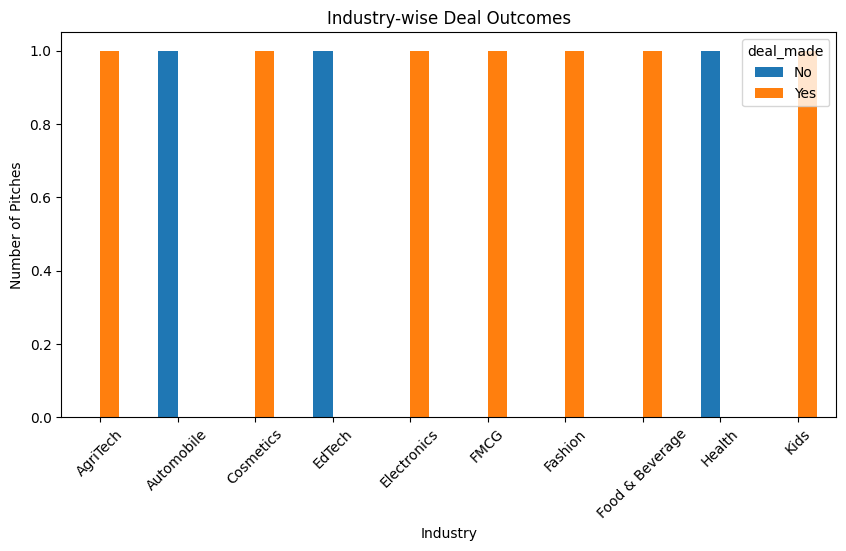

In [18]:
industry_deals.plot(kind="bar", figsize=(10,5))
plt.title("Industry-wise Deal Outcomes")
plt.xlabel("Industry")
plt.ylabel("Number of Pitches")
plt.xticks(rotation=45)
plt.show()


3.4 Key Insight Question 
## Industry Insights
- Industries with highest deal success:
- Industries with most rejections:
- Possible business reasons:


3.5 Save Progress (Professional Habit)

In [20]:
df.to_csv("data/processed/shark_tank_india_clean.csv", index=False)


STEP 4: PROFITABILITY vs DEAL SUCCESS ANALYSIS

4.1 Check Profitability Distribution

In [21]:
df["profitable"].value_counts()


profitable
Yes    6
No     4
Name: count, dtype: int64

4.2 Profitability vs Deal Outcome (Core Analysis)

In [22]:
profit_deal = (
    df.groupby("profitable")["deal_made"]
      .value_counts()
      .unstack()
      .fillna(0)
)

profit_deal


deal_made,No,Yes
profitable,,
No,3.0,1.0
Yes,0.0,6.0


4.3 Convert to Percentages 

In [23]:
profit_deal_pct = profit_deal.div(profit_deal.sum(axis=1), axis=0) * 100
profit_deal_pct


deal_made,No,Yes
profitable,,
No,75.0,25.0
Yes,0.0,100.0


4.4 Visualize the Result

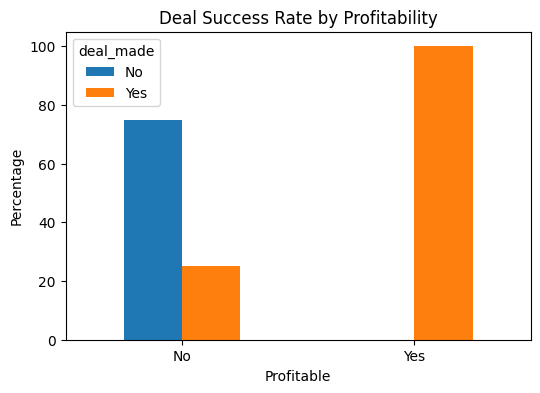

In [24]:
profit_deal_pct.plot(kind="bar", figsize=(6,4))
plt.title("Deal Success Rate by Profitability")
plt.xlabel("Profitable")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


4.5 Write the Insight
## Profitability Insights
- Profitable startups have a higher/lower deal success rate compared to non-profitable ones.
- Sharks appear to prefer/discourage early-stage loss-making startups.
- This suggests that profitability plays a significant/moderate role in investment decisions.


STEP 5: VALUATION vs EQUITY ANALYSIS

5.1 Calculate Implied Valuation (Very Important Concept)

In [25]:
df["implied_valuation"] = (df["amount_asked_lakhs"] / df["equity_asked_percent"]) * 100
df[["startup_name", "implied_valuation"]].head()


,startup_name,implied_valuation
0,Skippi,900.0
1,Blue Tea,7500.0
2,Hammer,10000.0
3,Revamp Moto,10000.0
4,CosIQ,500.0


5.2 Compare Valuation for Deals vs No Deals

In [26]:
df.groupby("deal_made")["implied_valuation"].median()


deal_made
No     1200.0
Yes    1000.0
Name: implied_valuation, dtype: float64

5.3 Visualize Valuation Distribution

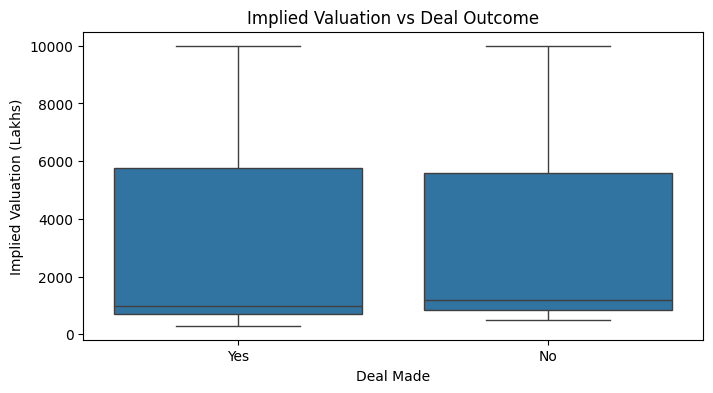

In [27]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="deal_made", y="implied_valuation")
plt.title("Implied Valuation vs Deal Outcome")
plt.xlabel("Deal Made")
plt.ylabel("Implied Valuation (Lakhs)")
plt.show()


5.4 Key Insight
## Valuation Insights
- Startups that secured deals generally had lower/more reasonable valuations.
- Extremely high valuation expectations often resulted in rejection.
- Sharks appear sensitive to valuation realism rather than just the idea.


5.5 Save Updated Processed Data

In [28]:
df.to_csv("data/processed/shark_tank_india_clean.csv", index=False)


STEP 6: SHARK-WISE INVESTMENT BEHAVIOR ANALYSIS

6.1 Inspect the sharks_invested Column

In [29]:
df["sharks_invested"].head()


0    Aman,Peyush
1        Ashneer
2           Aman
3            NaN
4         Namita
Name: sharks_invested, dtype: object

6.2 Split Sharks into Individual Records

In [30]:
shark_df = df[df["sharks_invested"] != ""].copy()

shark_df["shark"] = shark_df["sharks_invested"].str.split(",")
shark_df = shark_df.explode("shark")

shark_df["shark"] = shark_df["shark"].str.strip()

shark_df.head()


,season,startup_name,industry,deal_made,amount_asked_lakhs,equity_asked_percent,amount_deal_lakhs,equity_given_percent,valuation_lakhs,sharks_invested,profitable,implied_valuation,shark
0,1,Skippi,FMCG,Yes,45,5,45,5,900,"Aman,Peyush",Yes,900.0,Aman
0,1,Skippi,FMCG,Yes,45,5,45,5,900,"Aman,Peyush",Yes,900.0,Peyush
1,1,Blue Tea,Food & Beverage,Yes,75,1,75,1,7500,Ashneer,Yes,7500.0,Ashneer
2,1,Hammer,Electronics,Yes,100,1,100,1,10000,Aman,Yes,10000.0,Aman
3,1,Revamp Moto,Automobile,No,100,1,0,0,0,NaN,No,10000.0,NaN


6.3 Count Investments per Shark

In [31]:
shark_counts = shark_df["shark"].value_counts()
shark_counts


shark
Aman       2
Peyush     2
Ashneer    1
Namita     1
Anupam     1
Vineeta    1
Name: count, dtype: int64

6.4 Visualize Shark Investment Activity

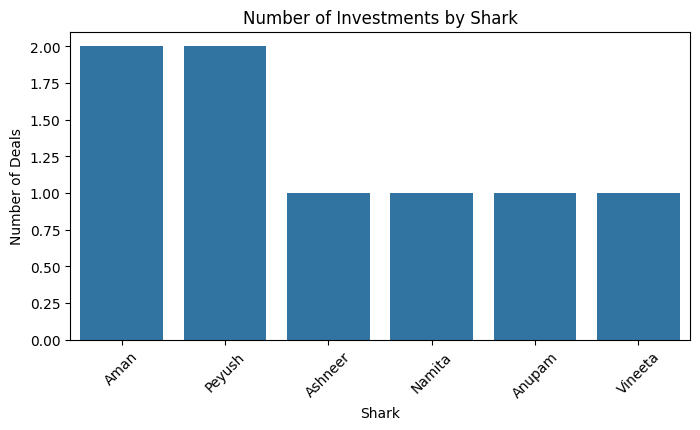

In [32]:
plt.figure(figsize=(8,4))
sns.barplot(x=shark_counts.index, y=shark_counts.values)
plt.title("Number of Investments by Shark")
plt.xlabel("Shark")
plt.ylabel("Number of Deals")
plt.xticks(rotation=45)
plt.show()


6.5 Solo vs Joint Deals (Advanced Insight)

In [35]:
df["num_sharks"] = df["sharks_invested"].fillna("").apply(
    lambda x: len(x.split(",")) if x != "" else 0
)


6.6 Write Shark Insights 
## Shark Investment Insights
- Some sharks are significantly more active than others.
- Joint deals are common in high-risk or high-valuation pitches.
- Shark preferences differ based on industry and valuation.


Save Progress (Final Save for EDA)

In [34]:
df.to_csv("data/processed/shark_tank_india_clean.csv", index=False)


In [36]:
df.groupby("num_sharks")["deal_made"].count()


num_sharks
0    3
1    6
2    1
Name: deal_made, dtype: int64

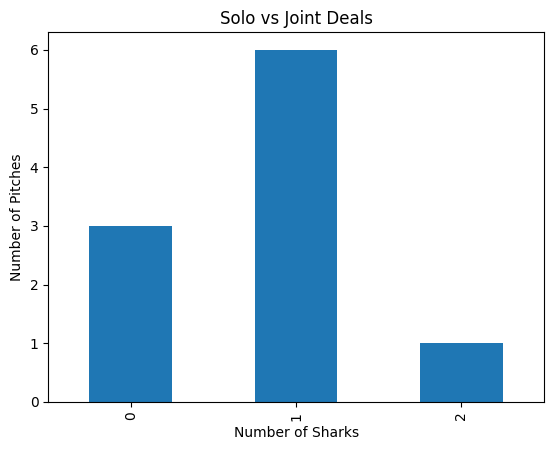

In [37]:
df["num_sharks"].value_counts().sort_index().plot(kind="bar")
plt.title("Solo vs Joint Deals")
plt.xlabel("Number of Sharks")
plt.ylabel("Number of Pitches")
plt.show()


STEP 7: FINALIZE THE PROJECT 

# Summary
## Key Insights
- Deal success varies significantly across industries, with some sectors consistently receiving more investments.
- Profitability positively influences deal outcomes, though strong ideas can still secure funding.
- Startups with realistic valuations are more likely to close deals.
- Certain sharks are more active investors, and joint deals typically occur in higher-stake pitches.
- Solo deals are more common than joint deals.

## Business Implications
- Founders should set realistic valuations and clearly communicate profitability.
- Sharks prefer balanced risk with clear growth potential.
- Industry dynamics play a strong role in investment decisions.


7.2 Clean Save (Final Dataset)

In [38]:
df.to_csv("data/processed/shark_tank_india_clean.csv", index=False)


README.md

# Shark Tank India – Data Exploration

## Project Objective
Analyze Shark Tank India pitch data to uncover patterns in deal success, valuation expectations, profitability impact, and shark investment behavior.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Analyses
- Industry-wise deal success
- Profitability vs funding outcomes
- Valuation and equity expectations
- Shark-wise investment behavior
- Solo vs joint deals

## Folder Structure
